<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/03a_FASHION_KDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# BLOQUE 1: MLOps - Entorno, Drive, KDM y Repo
# ==========================================
import os
import sys
from google.colab import drive

# 1. CONEXIÓN A DRIVE Y GITHUB (Vía token seguro)
print("--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---")
drive.mount('/content/drive', force_remount=True)
CARPETA_DRIVE = '/content/drive/MyDrive/01.Maestria/MLOps'

# Aseguramos que el script de setup esté en el path
if CARPETA_DRIVE not in sys.path:
    sys.path.append(CARPETA_DRIVE)

import setup_env

# Esto lee el token y clona/actualiza el repo automáticamente
setup_env.init_project(drive_token_path=f"{CARPETA_DRIVE}/github_token.txt")

# 2. CONFIGURACIÓN DEL REPOSITORIO PRINCIPAL
REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

# 3. INSTALACIÓN DE DEPENDENCIAS EXTERNAS (KDM)
print("\n--- INSTALANDO LIBRERÍA KDM ---")
os.chdir('/content')
if not os.path.exists('/content/kdm'):
    !git clone https://github.com/fagonzalezo/kdm.git /content/kdm

!pip install -q -e /content/kdm

# Limpiar path por si acaso y añadir KDM al principio
if '/content/kdm' in sys.path: sys.path.remove('/content/kdm')
sys.path.insert(0, '/content/kdm')

# 4. CORRECCIÓN DE BUGS DE ENTORNO (Refresco mágico)
!pip install -q --upgrade scikit-learn scipy
import site
site.main()

# Importaciones base necesarias para el resto del notebook
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Volvemos al repositorio para trabajar desde allí
os.chdir(REPO_PATH)
print(f"\n[✅] Entorno MLOps configurado perfectamente. Directorio actual: {os.getcwd()}")

--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---
Mounted at /content/drive
🚀 Iniciando configuración del entorno MLOps...
[*] Clonando el repositorio Analisis-KDM-PNC...
[*] Directorio de trabajo establecido en: /content/Analisis-KDM-PNC
[*] Credenciales de Git configuradas.

[✅ ÉXITO] Entorno listo. Ya puedes importar módulos de Analisis-KDM-PNC.

--- INSTALANDO LIBRERÍA KDM ---
Cloning into '/content/kdm'...
remote: Enumerating objects: 558, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 558 (delta 33), reused 36 (delta 26), pack-reused 502 (from 1)
Receiving objects: 100% (558/558), 61.81 MiB | 15.05 MiB/s, done.
Resolving deltas: 100% (328/328), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for kdm (pyproject.toml) ... done
     ━

In [2]:
# ==========================================
# BLOQUE 2: CARGA DE DATOS Y CONFIGURACIÓN (KDM - FASHION)
# ==========================================
import yaml
import sys
import os
import numpy as np # <--- AGREGADO: Necesario para np.unique al final

# 1. Importar tus módulos personalizados del repositorio
REPO_PATH = "/content/Analisis-KDM-PNC"
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

# CAMBIO CLAVE: Importar la clase de Fashion que creamos
from src.data.dataset_loaders import FashionKDMDataPipelineKFold

# 2. Cargar Configuración desde el archivo YAML
# Asegúrate de que la ruta coincida exactamente con la ubicación de tu YAML
PATH_CONFIG = os.path.join(REPO_PATH, 'configs/fashion_mnist/kdm.yaml')

print(f"[INFO] Leyendo configuración desde: {PATH_CONFIG}")
with open(PATH_CONFIG, 'r') as f:
    config_global = yaml.safe_load(f)

# Extraer parámetros específicos para facilidad de uso
params_grid = config_global.get('grid_search', {}).get('param_grid', {})
print(f"[✅] Configuración cargada. Espacio de búsqueda: {params_grid}")

# 3. Inicializar el Pipeline de Datos (Fashion-MNIST)
print("\n[INFO] Iniciando Pipeline de datos para Fashion-MNIST...")
# Usamos la carpeta data_fashion para no mezclar con los números de MNIST
pipeline = FashionKDMDataPipelineKFold(data_dir=f'{REPO_PATH}/data_fashion')

# Extraemos todo a NumPy usando el método que definimos en la clase
X_train_full, y_train_full, X_test, y_test = pipeline.get_all_numpy_data()

# 4. Verificación de Integridad
print("-" * 30)
print(f"RESUMEN DE CARGA (KDM - FASHION):")
print(f"  - Registros Entrenamiento: {X_train_full.shape[0]}")
print(f"  - Registros Test:          {X_test.shape[0]}")
print(f"  - Dimensiones (Flatten):   {X_train_full.shape[1]}")
print(f"  - Clases detectadas:       {len(np.unique(y_train_full))}")
print(f"  - Etiquetas de muestra:    {pipeline.class_names[:3]}...")
print("-" * 30)

[INFO] Leyendo configuración desde: /content/Analisis-KDM-PNC/configs/fashion_mnist/kdm.yaml
[✅] Configuración cargada. Espacio de búsqueda: {'n_comp': [256, 512], 'encoded_size': [64, 128], 'lr': [0.001, 0.0005], 'sigma': [0.5, 1.0]}

[INFO] Iniciando Pipeline de datos para Fashion-MNIST...
Cargando datasets Fashion-MNIST para KDM...
------------------------------
RESUMEN DE CARGA (KDM - FASHION):
  - Registros Entrenamiento: 60000
  - Registros Test:          10000
  - Dimensiones (Flatten):   784
  - Clases detectadas:       10
  - Etiquetas de muestra:    ['T-shirt/top', 'Trouser', 'Pullover']...
------------------------------


In [3]:
params_grid

{'n_comp': [256, 512],
 'encoded_size': [64, 128],
 'lr': [0.001, 0.0005],
 'sigma': [0.5, 1.0]}

In [4]:
# ==========================================
# BLOQUE 3: GRID SEARCH CON TRAZABILIDAD TOTAL (FAST-TRACK)
# ==========================================
import itertools
import time
import pandas as pd
import numpy as np
import yaml
import os
from sklearn.model_selection import KFold
# Importaciones específicas del ecosistema KDM y PNC
from src.models.kdm_factory import build_kdm_model

# 1. Configuración de Rutas (Contexto de Tesis)
# Definimos Fashion-MNIST como dataset de referencia inicial según tu propuesta [cite: 38]
REPO_PATH = os.getcwd()
ruta_base = os.path.join(REPO_PATH, "resultados/fashion")
os.makedirs(f"{ruta_base}/metricas", exist_ok=True)
ruta_mejores_params = f"{ruta_base}/metricas/best_kdm_params.yaml"
ruta_historial_csv = f"{ruta_base}/metricas/gridsearch_history.csv"

# 2. Lógica de Ejecución Eficiente
if os.path.exists(ruta_mejores_params):
    print(f"[⏩] Salto de búsqueda: Parámetros encontrados en {ruta_mejores_params}")
    with open(ruta_mejores_params, 'r') as file:
        mejor_config = yaml.safe_load(file)
else:
    print("[⏳] Iniciando Grid Search Estratégico (33% sample)...")

    # Submuestreo para reducir tiempo de computación (Objetivo 3) [cite: 89]
    SAMPLE_FRACTION = 0.33
    np.random.seed(42)
    idx_sample = np.random.choice(len(X_train_full), int(len(X_train_full) * SAMPLE_FRACTION), replace=False)
    X_sample, y_sample = X_train_full[idx_sample], y_train_full[idx_sample]

    grid_configs = [dict(zip(params_grid.keys(), v)) for v in itertools.product(*params_grid.values())]
    resultados_grid = []
    mejor_val_acc = 0.0

    # Cross-validation para robustez estadística [cite: 95]
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for idx, conf in enumerate(grid_configs):
        print(f"Evaluando {idx+1}/{len(grid_configs)}: {conf}")
        fold_accs = []
        start_conf = time.time()

        for fold, (t_idx, v_idx) in enumerate(kf.split(X_sample)):
            # Factoría de modelos basada en el marco unificado de KDM [cite: 44]
            modelo, n_params = build_kdm_model(conf, X_sample[t_idx], y_sample[t_idx])

            # Entrenamiento con Early Stopping implícito en pocas épocas para screening
            hist = modelo.fit(X_sample[t_idx], y_sample[t_idx],
                              validation_data=(X_sample[v_idx], y_sample[v_idx]),
                              epochs=5, batch_size=128, verbose=0)

            acc = hist.history['val_accuracy'][-1]
            fold_accs.append(acc)

        mean_acc = np.mean(fold_accs)
        # Registro de trazabilidad para análisis de estabilidad [cite: 95]
        conf_res = {**conf, 'mean_val_acc': mean_acc, 'total_params': n_params, 'time': time.time() - start_conf}
        resultados_grid.append(conf_res)

        if mean_acc > mejor_val_acc:
            mejor_val_acc, mejor_config = mean_acc, conf

    # Persistencia MLOps
    df_res = pd.DataFrame(resultados_grid).sort_values(by='mean_val_acc', ascending=False)
    df_res.to_csv(ruta_historial_csv, index=False)

    with open(ruta_mejores_params, 'w') as f:
        yaml.dump(mejor_config, f)
    print(f"[✅] Búsqueda finalizada. Mejores parámetros guardados.")

/content/kdm/kdm/utils.py:186: SyntaxWarning: invalid escape sequence '\p'
  Calculates the overlap of a state  \phi(x) with a density


[⏳] Iniciando Grid Search Estratégico (33% sample)...
Evaluando 1/16: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.001, 'sigma': 0.5}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Evaluando 2/16: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.001, 'sigma': 1.0}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Evaluando 3/16: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.0005, 'sigma': 0.5}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Evaluando 4/16: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.0005, 'sigma': 1.0}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Evaluando 5/16: {'n_comp': 256, 'encoded_size': 128, 'lr': 0.001, 'sigma': 0.5}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━

In [6]:
1

1

In [7]:
# ==========================================
# BLOQUE 4 y 5: ENTRENAMIENTO FINAL Y EVALUACIÓN
# ==========================================
import os
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from src.models.kdm_factory import build_kdm_model

# 1. Cargar la mejor configuración guardada
ruta_base = os.path.join(REPO_PATH, "resultados/fashion")
ruta_mejores_params = f"{ruta_base}/metricas/best_kdm_params.yaml"

print("--- INICIANDO ENTRENAMIENTO DEFINITIVO ---")
with open(ruta_mejores_params, 'r') as file:
    mejor_config = yaml.safe_load(file)
print(f"[INFO] Entrenando con la configuración campeona: {mejor_config}")

# 2. Separar un set de validación del conjunto total (10%) para monitorear el sobreajuste
X_t, X_v, y_t, y_v = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)

# 3. Construir el modelo final
# Usamos toda la data para inicializar las componentes de KDM
modelo_final, total_params = build_kdm_model(mejor_config, X_train_full, y_train_full)
print(f"[INFO] Parámetros totales del modelo KDM final: {total_params}")

# 4. Entrenamiento a fondo
EPOCHS_FINALES = 10 # Épocas suficientes para que el modelo converja
start_time = time.time()

history = modelo_final.fit(
    X_t, y_t,
    validation_data=(X_v, y_v),
    epochs=EPOCHS_FINALES,
    batch_size=128,
    verbose=1
)
tiempo_entrenamiento = time.time() - start_time
print(f"\n[✅] Entrenamiento finalizado en {tiempo_entrenamiento:.2f} segundos.")


--- INICIANDO ENTRENAMIENTO DEFINITIVO ---
[INFO] Entrenando con la configuración campeona: {'encoded_size': 128, 'lr': 0.001, 'n_comp': 256, 'sigma': 0.5}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[INFO] Parámetros totales del modelo KDM final: 269441.0
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.8222 - loss: 0.4965 - val_accuracy: 0.8447 - val_loss: 0.4389
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8692 - loss: 0.3625 - val_accuracy: 0.8692 - val_loss: 0.3642
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8825 - loss: 0.3218 - val_accuracy: 0.8712 - val_loss: 0.3525
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8890 - loss: 0.3013 - val_accuracy: 0.8753 - val_loss: 0.3395
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8945 - loss: 0.2820 - val_accuracy: 0.8838 - val_loss: 0.3256
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9004 - loss: 0.2698 - val_accur

In [8]:

# ==========================================
# EVALUACIÓN, GRÁFICAS Y GUARDADO (MLOps)
# ==========================================
os.makedirs(f"{ruta_base}/modelos", exist_ok=True)
os.makedirs(f"{ruta_base}/graficas", exist_ok=True)

print("\n--- GENERANDO PREDICCIONES Y MÉTRICAS DE TEST ---")
# 5. Predicciones en el conjunto de Test real (10,000 imágenes nunca antes vistas)
y_pred = np.argmax(modelo_final.predict(X_test), axis=1)


--- GENERANDO PREDICCIONES Y MÉTRICAS DE TEST ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [12]:
ruta_base

'/content/Analisis-KDM-PNC/resultados/fashion'

[💾] Pesos del modelo guardados en: /content/Analisis-KDM-PNC/resultados/fashion/modelos/kdm_fashion_best_model.weights.h5
[📊] Reporte detallado guardado en: /content/Analisis-KDM-PNC/resultados/fashion/metricas/mejor_kdm_report.csv
[🖼️] Gráfica de evaluación guardada en: /content/Analisis-KDM-PNC/resultados/fashion/graficas/resultado_final_fashion.png


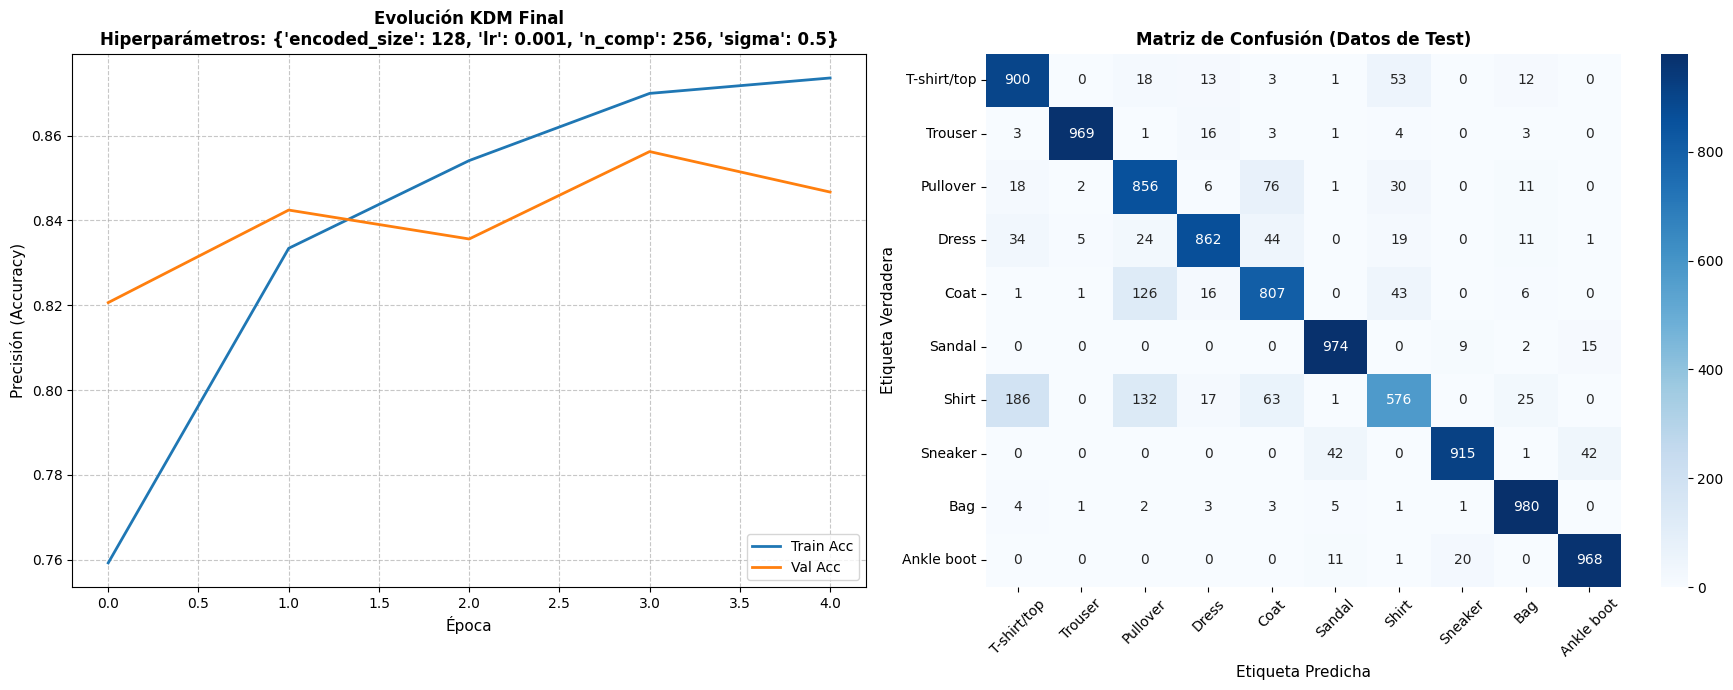


[🏁] Flujo completo finalizado. Entorno limpio y métricas almacenadas.


In [19]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# BLOQUE 6: GRÁFICAS Y MÉTRICAS (Fashion-MNIST)
# ==========================================

# 1. Definición estricta de las clases para interpretabilidad
nombres_clases_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Transformación de predicciones y etiquetas reales (De One-Hot a Índices)
# Asumimos que modelo_final.predict() retorna probabilidades (N, 10)
y_test_idx = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test
y_pred_idx = np.argmax(y_pred, axis=1) if y_pred.ndim > 1 else y_pred

# 3. Asegurar la existencia de directorios antes de guardar
os.makedirs(f"{ruta_base}/modelos", exist_ok=True)
os.makedirs(f"{ruta_base}/graficas", exist_ok=True)

# 4. Configuración del lienzo (Canvas)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfica 1: Curvas de Aprendizaje ---
ax[0].plot(hist.history['accuracy'], label='Train Acc', color='#1f77b4', linewidth=2)
ax[0].plot(hist.history['val_accuracy'], label='Val Acc', color='#ff7f0e', linewidth=2)
ax[0].set_title(f'Evolución KDM Final\nHiperparámetros: {mejor_config}', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Época', fontsize=11)
ax[0].set_ylabel('Precisión (Accuracy)', fontsize=11)
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.7)

# --- Gráfica 2: Matriz de Confusión ---
cm = confusion_matrix(y_test_idx, y_pred_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=nombres_clases_fashion, yticklabels=nombres_clases_fashion)
ax[1].set_title('Matriz de Confusión (Datos de Test)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Etiqueta Predicha', fontsize=11)
ax[1].set_ylabel('Etiqueta Verdadera', fontsize=11)
ax[1].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='y', rotation=0)

plt.tight_layout()

# ==========================================
# BLOQUE 7: GUARDADO FÍSICO Y PERSISTENCIA
# ==========================================

# Guardar pesos
ruta_pesos = f"{ruta_base}/modelos/kdm_fashion_best_model.weights.h5"
modelo_final.save_weights(ruta_pesos)
print(f"[💾] Pesos del modelo guardados en: {ruta_pesos}")

# Guardar reporte de clasificación con NOMBRES DE CLASES
report = classification_report(y_test_idx, y_pred_idx, target_names=nombres_clases_fashion, output_dict=True)
df_report = pd.DataFrame(report).transpose()
ruta_reporte = f"{ruta_base}/metricas/mejor_kdm_report.csv"
df_report.to_csv(ruta_reporte)
print(f"[📊] Reporte detallado guardado en: {ruta_reporte}")

# Guardar gráfica en alta resolución
ruta_grafica = f"{ruta_base}/graficas/resultado_final_fashion.png"
fig.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
print(f"[🖼️] Gráfica de evaluación guardada en: {ruta_grafica}")

plt.show()

# ==========================================
# BLOQUE 8: LIMPIEZA DEL ENTORNO MLOps
# ==========================================
# Usamos glob y os para limpieza multiplataforma (mejor que comandos bash en cuadernos)
archivos_pyc = glob.glob("**/*.pyc", recursive=True)
for p in archivos_pyc:
    try:
        os.remove(p)
    except OSError:
        pass
print(f"\n[🏁] Flujo completo finalizado. Entorno limpio y métricas almacenadas.")

In [20]:
# ==========================================
# BLOQUE 6: SINCRONIZACIÓN MLOPS (VERSIÓN ROBUSTA)
# ==========================================
import os

REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)

print("--- REPARANDO Y SINCRONIZANDO REPOSITORIO ---")

# 1. Configuración de identidad
!git config --global user.email "bspd1007@gmail.com"
!git config --global user.name "bspd1007 (Google Colab)"

# 2. LIMPIEZA RADICAL DE CACHÉ (Evita el error de 'unstaged changes')
# Marcamos los borrados de __pycache__ como parte del stage o los ignoramos
!find . -name "__pycache__" -type d -exec rm -rf {} +
!git add -u # Registra todos los archivos borrados/modificados en el index

# 3. SINCRONIZACIÓN FORZADA
print("\n[INFO] Trayendo cambios del remoto (Pull Rebase)...")
# Usamos autostash para que si hay algo pendiente lo guarde y lo devuelva solo
!git pull origin main --rebase --autostash

# 4. ADICIÓN DE RESULTADOS CIENTÍFICOS
print("\n[INFO] Indexando nuevos resultados...")
if os.path.exists("resultados/fashion/"):
    !git add resultados/fashion/
else:
    print("[⚠️] Alerta: No se encontró la carpeta de resultados/fashion")

# 5. COMMIT Y PUSH
MENSAJE_COMMIT = "fix(mlops): sincronización de métricas Fashion-MNIST tras limpieza de caché"
# Solo hacemos commit si hay cambios reales
!git diff-index --quiet HEAD || git commit -m "{MENSAJE_COMMIT}"

print("\n[INFO] Empujando a GitHub...")
!git push origin main

print("\n[🏁] Si no ves mensajes de 'error' arriba, la sincronización es REAL.")

--- REPARANDO Y SINCRONIZANDO REPOSITORIO ---

[INFO] Trayendo cambios del remoto (Pull Rebase)...
From https://github.com/Steven10P/Analisis-KDM-PNC
 * branch            main       -> FETCH_HEAD
Already up to date.

[INFO] Indexando nuevos resultados...
[main 5bb5fb9] fix(mlops): sincronización de métricas Fashion-MNIST tras limpieza de caché
 2 files changed, 0 insertions(+), 0 deletions(-)
 delete mode 100644 src/__pycache__/__init__.cpython-312.pyc
 delete mode 100644 src/utils/__pycache__/__init__.cpython-312.pyc

[INFO] Empujando a GitHub...
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 412 bytes | 412.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Steven10P/Analisis-KDM-PNC.git
   9d540db..5bb5fb9  main -> main

[🏁] Si no ves mensajes de 'er

In [22]:
# ==========================================
# BLOQUE DE RESCATE: FORZAR SUBIDA DEL MODELO
# ==========================================
import os

REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)

print("--- DIAGNÓSTICO LOCAL ---")
# 1. Verificamos que el archivo físico esté en el Colab
!ls -lh resultados/fashion/modelos/

print("\n--- FORZANDO LA INSERCIÓN A GIT ---")
# 2. El parámetro -f (force) obliga a Git a ignorar el .gitignore
!git add -f resultados/fashion/modelos/kdm_fashion_best_model.weights.h5

# Verificamos si Git ahora sí lo tiene en la mira
!git status -s

# 3. Nuevo commit y push
!git commit -m "fix(KDM): Forzando la subida de los pesos del modelo .h5 ignorando .gitignore"
!git push origin main

print("\n[✅] Rescate finalizado. Revisa tu GitHub ahora, el archivo .h5 debería estar allí.")

--- DIAGNÓSTICO LOCAL ---
total 8.7M
-rw-r--r-- 1 root root 3.2M Apr  9 13:20 kdm_best_model.weights.h5
-rw-r--r-- 1 root root 3.2M Apr  9 13:24 kdm_fashion_best_model.weights.h5
-rw-r--r-- 1 root root 1.2M Apr  9 12:41 mejor_pnc_fashion.pth
-rw-r--r-- 1 root root 1.2M Apr  9 12:41 pnc_fashion_best_model.pth

--- FORZANDO LA INSERCIÓN A GIT ---
A  resultados/fashion/modelos/kdm_fashion_best_model.weights.h5
[main c5f1540] fix(KDM): Forzando la subida de los pesos del modelo .h5 ignorando .gitignore
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 resultados/fashion/modelos/kdm_fashion_best_model.weights.h5
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 521 bytes | 521.00 KiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Steven10P/Anali